# `AnalyticalFRC` demo

The `AnalyticalFRC` object is the main entry point of the package. It takes a single amino acid sequence and provides analytical Flory Random Coil (theta-state) polymer statistics for that sequence.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from afrc import AnalyticalFRC

seq = 'MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYG'
P = AnalyticalFRC(seq)
len(P)

51

## Ensemble-average dimensions

All of these are returned instantly - no simulation required.

In [3]:
print(f"mean Re (scaling law) : {P.get_mean_end_to_end_distance():.2f} A")
print(f"mean Rg (distribution): {P.get_mean_radius_of_gyration():.2f} A")
print(f"mean Rh (Kirkwood)    : {P.get_mean_hydrodynamic_radius('kirkwood-riseman'):.2f} A")
print(f"mean Rh (Nygaard)     : {P.get_mean_hydrodynamic_radius('nygaard'):.2f} A")

mean Re (scaling law) : 41.44 A
mean Rg (distribution): 17.76 A
mean Rh (Kirkwood)    : 17.98 A
mean Rh (Nygaard)     : 19.48 A


## End-to-end and radius-of-gyration distributions

The distribution getters return a `(distances, probabilities)` tuple.

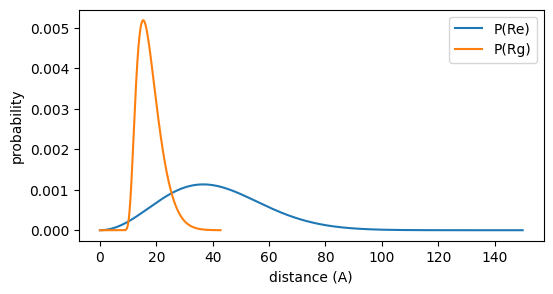

In [4]:
re_r, re_p = P.get_end_to_end_distribution()
rg_r, rg_p = P.get_radius_of_gyration_distribution()

plt.figure(figsize=(6, 3))
plt.plot(re_r, re_p, label='P(Re)')
plt.plot(rg_r, rg_p, label='P(Rg)')
plt.xlabel('distance (A)')
plt.ylabel('probability')
plt.legend()
plt.show()

## Internal scaling profile

Average inter-residue distance as a function of sequence separation |i-j|. On a log-log plot the slope is the apparent scaling exponent, which for the AFRC is ~0.5.

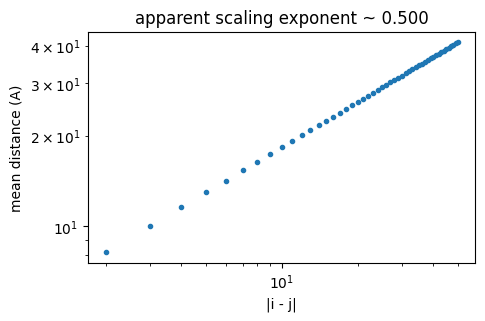

In [5]:
iscaling = P.get_internal_scaling()
sep, dist = iscaling[:, 0], iscaling[:, 1]
slope = np.polyfit(np.log(sep[1:]), np.log(dist[1:]), 1)[0]

plt.figure(figsize=(5, 3))
plt.loglog(sep[1:], dist[1:], 'o', ms=3)
plt.xlabel('|i - j|')
plt.ylabel('mean distance (A)')
plt.title(f'apparent scaling exponent ~ {slope:.3f}')
plt.show()

## Contact map

The expected fraction of the time each residue pair sits within a distance threshold (here 20 A).

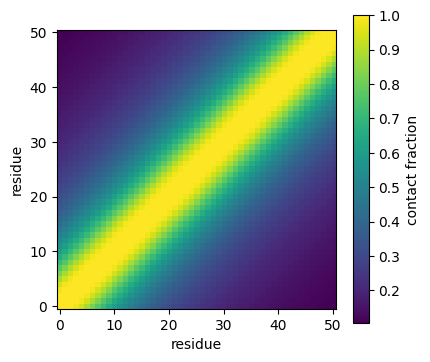

In [6]:
cmap = P.get_contact_map(20.0, symmetric_map=True)

plt.figure(figsize=(4.5, 4))
plt.imshow(cmap, origin='lower', cmap='viridis')
plt.colorbar(label='contact fraction')
plt.xlabel('residue')
plt.ylabel('residue')
plt.show()

## Sampling

Draw an uncorrelated 'trajectory' of values from a distribution - useful for building a size-matched reference for simulations or experiments.

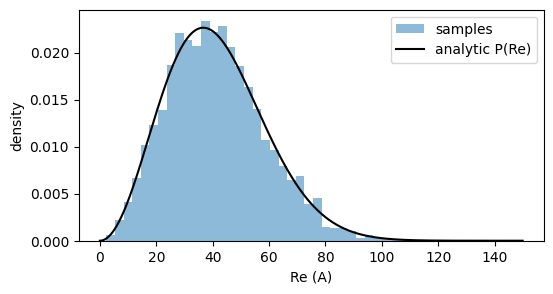

In [7]:
samples = P.sample_end_to_end_distribution(n=5000)
dx = re_r[1] - re_r[0]

plt.figure(figsize=(6, 3))
plt.hist(samples, bins=40, density=True, alpha=0.5, label='samples')
plt.plot(re_r, re_p / dx, 'k', label='analytic P(Re)')
plt.xlabel('Re (A)')
plt.ylabel('density')
plt.legend()
plt.show()